# 지도학습 - 분류 둘러보기

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
import sklearn

sklearn.__version__

'1.8.0'

In [2]:
# Mac 기준 한글 폰트 설정
plt.rcParams["font.family"] = "AppleGothic"
# 마이너스 부호 깨짐 문제 방지
plt.rcParams["axes.unicode_minus"] = False

## 생선 이진 분류 - 도미냐? 빙어냐?
<table>
    <tr>
        <td><img src="https://d.pr/i/FaQ4RH+" width="300"></td>
        <td><img src="https://d.pr/i/NmXwPX+" width="300"></td>
    </tr>
</table>

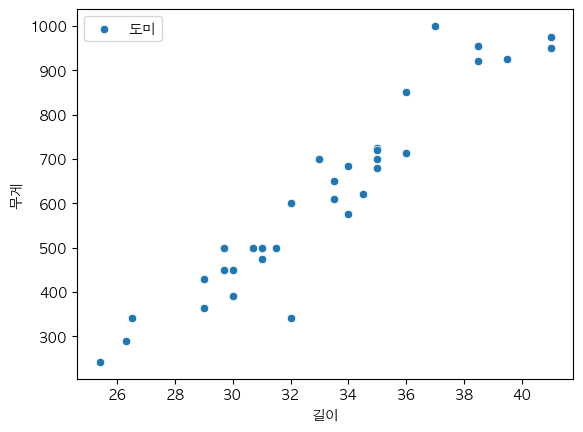

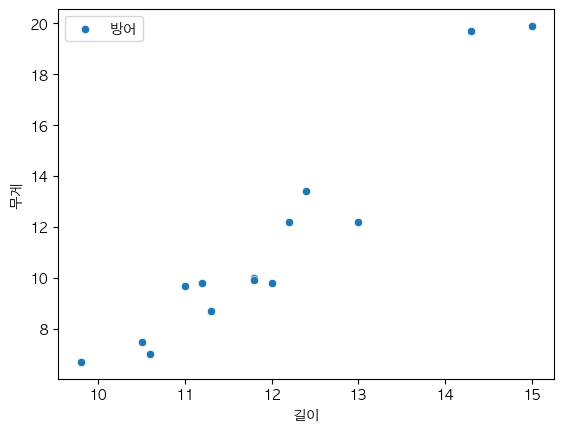

In [5]:
# 도미 데이터
bream_length = [25.4, 26.3, 26.5, 29.0, 29.0, 29.7, 29.7, 30.0, 30.0, 30.7, 31.0, 31.0, 31.5, 32.0, 32.0, 32.0, 33.0, 33.0, 33.5, 33.5, 34.0, 34.0, 34.5, 35.0, 35.0, 35.0, 35.0, 36.0, 36.0, 37.0, 38.5, 38.5, 39.5, 41.0, 41.0]
bream_weight = [242.0, 290.0, 340.0, 363.0, 430.0, 450.0, 500.0, 390.0, 450.0, 500.0, 475.0, 500.0, 500.0, 340.0, 600.0, 600.0, 700.0, 700.0, 610.0, 650.0, 575.0, 685.0, 620.0, 680.0, 700.0, 725.0, 720.0, 714.0, 850.0, 1000.0, 920.0, 955.0, 925.0, 975.0, 950.0]

# 산포도 시각화
sns.scatterplot(x=bream_length, y=bream_weight, label="도미")
plt.xlabel("길이")
plt.ylabel("무게")
plt.show()

# 빙어 데이터 
smelt_length = [9.8, 10.5, 10.6, 11.0, 11.2, 11.3, 11.8, 11.8, 12.0, 12.2, 12.4, 13.0, 14.3, 15.0]
smelt_weight = [6.7, 7.5, 7.0, 9.7, 9.8, 8.7, 10.0, 9.9, 9.8, 12.2, 13.4, 12.2, 19.7, 19.9]
sns.scatterplot(x=smelt_length, y=smelt_weight, label="방어")
plt.xlabel("길이")
plt.ylabel("무게")
plt.show()

## 최근접이웃분류모델을 이용한 분류
- 데이터 포인트 간의 거리 기반으로 분류를 수행하는 모델

In [ ]:
# 학습을 위한 데이터 포맷
length = bream_length + smelt_length
weight = bream_weight + smelt_weight
print(len(bream_length), len(smelt_length))   # 도미 데이터 35개, 빙어 데이터 14개
print(len(length), len(weight))   # 길이 데이터 49개, 무게 데이터 49개

35 14
49 49


In [7]:
# 입력(X) : 길이, 무게 -> 특성(Feature)
fish_data = np.array([[l, w] for l, w in zip(length, weight)])
fish_data

array([[  25.4,  242. ],
       [  26.3,  290. ],
       [  26.5,  340. ],
       [  29. ,  363. ],
       [  29. ,  430. ],
       [  29.7,  450. ],
       [  29.7,  500. ],
       [  30. ,  390. ],
       [  30. ,  450. ],
       [  30.7,  500. ],
       [  31. ,  475. ],
       [  31. ,  500. ],
       [  31.5,  500. ],
       [  32. ,  340. ],
       [  32. ,  600. ],
       [  32. ,  600. ],
       [  33. ,  700. ],
       [  33. ,  700. ],
       [  33.5,  610. ],
       [  33.5,  650. ],
       [  34. ,  575. ],
       [  34. ,  685. ],
       [  34.5,  620. ],
       [  35. ,  680. ],
       [  35. ,  700. ],
       [  35. ,  725. ],
       [  35. ,  720. ],
       [  36. ,  714. ],
       [  36. ,  850. ],
       [  37. , 1000. ],
       [  38.5,  920. ],
       [  38.5,  955. ],
       [  39.5,  925. ],
       [  41. ,  975. ],
       [  41. ,  950. ],
       [   9.8,    6.7],
       [  10.5,    7.5],
       [  10.6,    7. ],
       [  11. ,    9.7],
       [  11.2,    9.8],


In [9]:
# 출력(y): 도미(1), 빙어(0) -> 라벨(label)
fish_target = np.array([1] * 35 + [0] * 14)
fish_target

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0])

In [10]:
# 문제, 정답 크기 비교
# X -> (샘플 수, 특성 수)
# y -> (샘플 수)
print(fish_data.shape)
print(fish_target.shape)

(49, 2)
(49,)


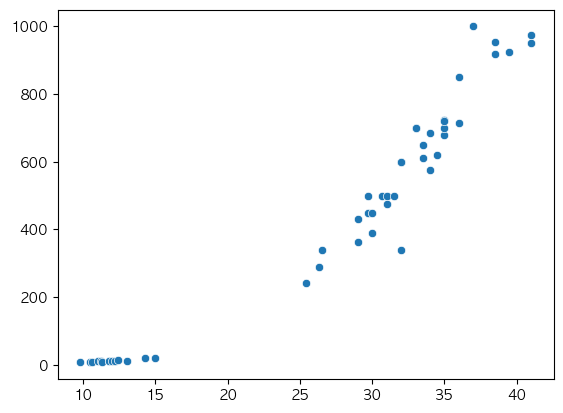

In [11]:
# 시각화
sns.scatterplot(x=fish_data[:,0], y=fish_data[:,1])
plt.show()

## k-최근접 이웃 알고리즘 작동 원리
최근접 이웃 알고리즘(K-Nearest Neighbors, KNN)은 거리를 구하는 방법으로 가장 일반적으로 사용 되는 방법은 **유클리드 거리(Euclidean distance)** 이다. 
유클리드 거리는 "두 점 사이의 직선 거리"를 구하는 가장 간단한 방법이다. 

In [ ]:
# 모델 준비 scikit-learn의 KNN 분류가 클래스를 가져온다.
from sklearn.neighbors import KNeighborsClassifier

# 기본 설정의 KNN 모델 생성
# 기본 값으로 n_neighbors=5 이다 => 가장 가까운 이웃 5개를 보고 다수결로 분류한다.
kn_clf = KNeighborsClassifier()
kn_clf

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [ ]:
# 모델 학습
# fit(X, y) : 입력 데이터(X)와 정답(y)를 모델에 전달한다.
# KNN은 복잡한 수식을 학습하기 보다는 학습 데이터를 내부에 저장해두고 예측 시 거리를 계산하는 방식
kn_clf.fit(fish_data, fish_target)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [14]:
# 모델 성능 평가
# score(X, y) : 주어진 데이터에 대한 정확도를 계산한다.
kn_clf.score(fish_data, fish_target)

1.0

In [15]:
# 모델 예측
#predict() : 새로운 입력에 대해 클래스를 예측한다.
kn_clf.predict([[40, 500], [10, 10]])   # 도미, 빙어 예측 성공

array([1, 0])

[[ 8.5         9.          9.3        10.3        26.57066051]] [[12 11  9  6 10]]


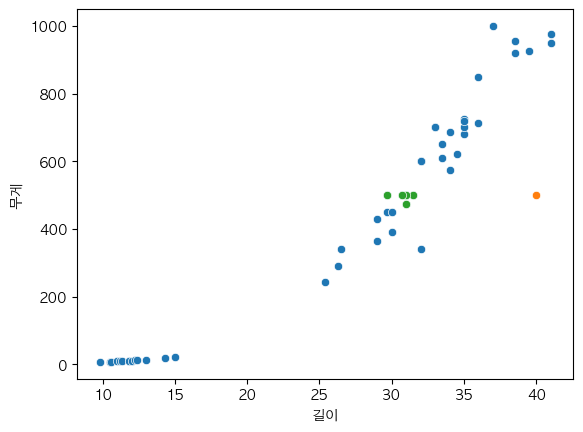

In [17]:
# 이웃 확인
# distance : 각 이웃까지의 거리, index : 원본 학습 데이터에서 그 이웃들이 몇 번째 샘플인지
distance, index = kn_clf.kneighbors([[40, 500]])
print(distance, index)

# 최근접 이웃 target 확인
# 5개의 이웃 모두 도미이기 때문에 다수결로 도미로 판단함
fish_target[index]

# 시각화
sns.scatterplot(x=fish_data[:,0], y=fish_data[:,1])  # 학습 데이터
sns.scatterplot(x=[40], y=[500])
index = index.squeeze()  # 2차원 -> 1차원
sns.scatterplot(x=fish_data[index,0], y=fish_data[index, 1])  # 최근접 이웃

plt.xlabel("길이")
plt.ylabel("무게")
plt.show()

## 학습/테스트 세트 분리
위에서는 KNN의 동작 원리를 확인해 보았다. 이제부터는 이 모델을 믿어도 되는지를 확인한다.
- 학습용 데이터(train set): 모델이 공부하는 데이터
- 테스트용 데이터(test set): 학습에 쓰지 않고 마지막에 실력을 검사하는 데이터

In [ ]:
from sklearn.model_selection import train_test_split

# train_test_split : 전체 데이터를 학습용과 테스트용으로 나눈다.
(X_train, X_test, y_train, y_test) = train_test_split(fish_data, fish_target, stratify=fish_target, test_size=0.2, random_state=42)

# 분리 결과 확인
print('X_train:', X_train.shape)
print('y_train:', y_train.shape)
print('X_test:', X_test.shape)
print('y_test:', y_test.shape)

In [19]:
# 다시 모델 준비
kn_clf = KNeighborsClassifier()

# 학습
kn_clf.fit(X_train, y_train)    # 학습용 데이터 사용

# 성능 평가
kn_clf.score(X_test, y_test)

# 예측 (테스트 데이터 전체에 대한 예측, 실제 정답과 비교)
print(kn_clf.predict(X_test))
print(y_test)

[1 0 1 1 0 1 1 1 0 1]
[1 0 1 1 0 1 1 1 0 1]


## 수상한 도미
도미 (길이 25, 무게 150)의 문제

In [ ]:
# 실제 데이터는 도미이지만 빙어로 판단 되는 결과
kn_clf.predict([[25, 150]])

array([0])

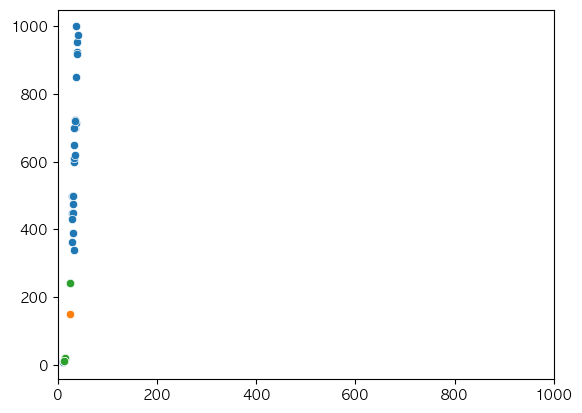

In [25]:
# 시각화
sns.scatterplot(x=X_train[:,0], y=X_train[:,1])    # 학습 데이터
sns.scatterplot(x=[25], y=[150])                   # 문제 (예측)
distance, index = kn_clf.kneighbors([[25, 150]])   
sns.scatterplot(x=X_train[index.squeeze(), 0], y=X_train[index.squeeze(), 1])  # 최근접 이웃 표시

# 길이(10~40)보다 무게(0~1000)의 스케일이 훨씬 크기 때문에 거리 계싼에서 무게가 큰 영향력을 갖게 되었음
plt.xlim(0, 1000)
plt.show()

## 표준 점수 스케일링
서로 다른 속성의 값의 범위를 맞추기 위한 전처리 기법. 

In [ ]:
from sklearn.preprocessing import StandardScaler

# 다시 학습/테스트 분리